## 1. Setup and Imports



In [ ]:
%%capture
!pip install "datasets>=2.18.0,<3" transformers>=4.38.2 sentence-transformers>=2.5.1 setfit>=1.0.3 accelerate>=0.27.2 seqeval>=1.2.2 accelerate==0.31.0 peft==0.11.1 bitsandbytes==0.43.1 transformers==4.41.2 trl==0.9.4 sentencepiece==0.2.0 triton==3.1.0

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
import evaluate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# --- Device Check ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Environment ready.")
print(f"   PyTorch version : {torch.__version__}")
print(f"   Active device   : {device.upper()}")
print(f"   GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU name        : {torch.cuda.get_device_name(0)}")

Environment ready.
   PyTorch version : 2.5.1+cu124
   Active device   : CUDA
   GPU available   : True
   GPU name        : Tesla T4


## 2. Load and Inspect Classification Data
**What this step does:** This step loads the `yelp_review_full` dataset and then examines its structure, size, and class distribution before we any modeling.

**Why it matters:** This matters because we have to first understand what the data looks like. How balanced is it? Are all the categories well represented? Are the examples realistic? We try to minimize the imalances and bias that might impact our model downstream now before it gets fed for training.


**About the Dataset:**  
`yelp_review_full` contains customer reviews labeled with 1 through 5 stars.
In our business context, we treat these as:

| Label | Stars | Business Interpretation         |
|-------|-------|----------------------------------|
| 0     | 1-star    | Severe complaint — immediate escalation needed |
| 1     | 2-star  | Significant dissatisfaction — follow-up required |
| 2     | 3-star | Neutral/mixed — monitor for trends |
| 3     | 4-star | Satisfied customer — retention opportunity |
| 4     | 5-star | Promoter — candidate for referral programs |

Training examples   : 3,250
Validation examples : 250

Feature columns     : ['label', 'text']
Label range         : 0 – 4

--- Training Set Class Distribution ---
 Stars  Count  Pct (%)    Business Tier
1-Star    689     21.2 Severe Complaint
2-Star    665     20.5     Dissatisfied
3-Star    601     18.5    Neutral/Mixed
4-Star    669     20.6        Satisfied
5-Star    626     19.3         Promoter


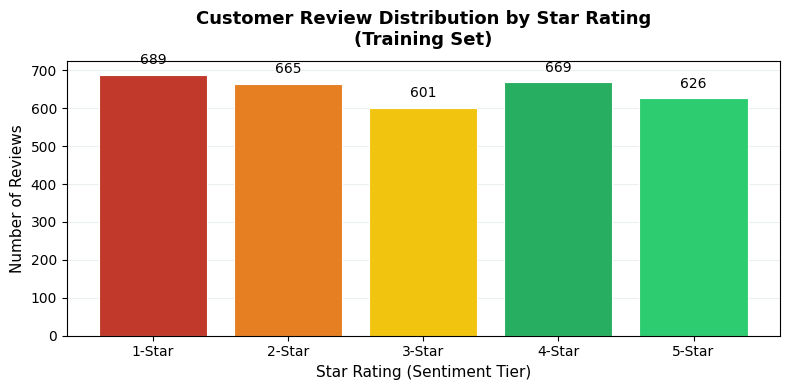


--- Example Reviews Per Class ---

[1-Star] We were excited to eat here, it is difficult to find. They were closed at 3 p.m. on a Saturday....

[2-Star] Where to begin...I think I will start with the positive.   The brie brulee topped with the caramelized apple slices was a hit, the mixed green salad with goat cheese was awesome and the pear tart dese...

[3-Star] who really knows if this is good pho or not, i was hung tha fuck over and in desperate need of pho therapy. :P but it totally hit the spot and came out super freakin fast!!! omg! aaahhhhh.....\n\ni'm...

[4-Star] I've been going here a lot(pretty much a regular you could say.) It's a good place to include in your bar hopping plans. Wandos too busy? Fooseball taken at Vintage? Swing by Red Shed. It's also one o...

[5-Star] I stalk this truck.  I've been to industrial parks where I pretend to be a tech worker standing in line, strip mall parking lots, and of course the farmer's market.  The bowls are so so absolutely div...


In [ ]:
# Load the full dataset
raw_dataset = load_dataset("yelp_review_full")

# --- Subsample for practical training on a free GPU ---
# Here we use a sample 200 times smaller than the original 650,000 train and 50,000 test; this makes sure the distribution is still as balanced as much as possible
TRAIN_SIZE = 3250
TEST_SIZE  = 250
SEED       = 42

train_data = raw_dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_data  = raw_dataset["test"].shuffle(seed=SEED).select(range(TEST_SIZE))

print(f"Training examples   : {len(train_data):,}")
print(f"Validation examples : {len(test_data):,}")
print(f"\nFeature columns     : {train_data.column_names}")
print(f"Label range         : {min(train_data['label'])} – {max(train_data['label'])}")

# --- Class Distribution ---
label_names = ["1-Star", "2-Star", "3-Star", "4-Star", "5-Star"]
train_labels = train_data["label"]
counts = pd.Series(train_labels).value_counts().sort_index()

dist_df = pd.DataFrame({
    "Stars": label_names,
    "Count": counts.values,
    "Pct (%)": (counts.values / len(train_labels) * 100).round(1),
    "Business Tier": ["Severe Complaint", "Dissatisfied", "Neutral/Mixed",
                      "Satisfied", "Promoter"]
})
print("\n--- Training Set Class Distribution ---")
print(dist_df.to_string(index=False))

# --- Visualize Distribution ---
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60", "#2ecc71"]
bars = ax.bar(label_names, counts.values, color=colors, edgecolor="white", linewidth=0.8)
ax.set_title("Customer Review Distribution by Star Rating\n(Training Set)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Star Rating (Sentiment Tier)", fontsize=11)
ax.set_ylabel("Number of Reviews", fontsize=11)
ax.grid(axis="y", color="#ECEFF1", linewidth=0.8)
ax.set_axisbelow(True)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{count:,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Example Texts Per Class ---
print("\n--- Example Reviews Per Class ---")
for label_id, label_name in enumerate(label_names):
    examples = [ex["text"] for ex in train_data if ex["label"] == label_id]
    print(f"\n[{label_name}] {examples[0][:200].strip()}...")

In [ ]:
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

## 3. Preprocessing and Tokenization

**What this step does:**
This step converts the raw review text into the tokens that BERT needs for processing

**Why it matters (Business Framing):**  
This matters because LLMs need tokens to process information. We also enforce a maximum length constraint to standardize the input format.

**Key decisions made here:**
- We use `bert-base-uncased`, which lowercases all text to simplify input (which is okay since capitalization doesn't hold much signal).
- `truncation=True` ensures reviews longer than 512 tokens are clipped at the
  model's capacity limit. Reviews exceeding this length are uncommon in practice. (Also a performance consideration).
- `DataCollatorWithPadding` dynamically pads each batch to its longest sequence
  rather than padding all examples to the global maximum.

In [ ]:
model_id = "bert-base-uncased"

# Load the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Dynamic padding: pads each batch to its longest sequence (memory-efficient)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess_function(examples):
    """Tokenize review text with truncation at BERT's 512-token limit."""
    return tokenizer(examples["text"], truncation=True)

# Apply tokenization across both splits in parallel (batched=True for speed)
tokenized_train = train_data.map(preprocess_function, batched=True)
tokenized_test  = test_data.map(preprocess_function, batched=True)

# --- Inspect a tokenized sample ---
sample_idx = 0
sample_text   = train_data[sample_idx]["text"]
sample_tokens = tokenizer(sample_text, truncation=True)

print(f"Original text (first 150 chars): {sample_text[:150]}")
print(f"\nToken IDs (first 20)           : {sample_tokens['input_ids'][:20]} ...")
print(f"Decoded tokens (first 20)      : {tokenizer.convert_ids_to_tokens(sample_tokens['input_ids'][:20])}")
print(f"Total token length             : {len(sample_tokens['input_ids'])}")
print(f"\nTraining split tokenized    : {len(tokenized_train):,} examples")
print(f"Validation split tokenized  : {len(tokenized_test):,} examples")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Original text (first 150 chars): I stalk this truck.  I've been to industrial parks where I pretend to be a tech worker standing in line, strip mall parking lots, and of course the fa

Token IDs (first 20)           : [101, 1045, 23899, 2023, 4744, 1012, 1045, 1005, 2310, 2042, 2000, 3919, 6328, 2073, 1045, 9811, 2000, 2022, 1037, 6627] ...
Decoded tokens (first 20)      : ['[CLS]', 'i', 'stalk', 'this', 'truck', '.', 'i', "'", 've', 'been', 'to', 'industrial', 'parks', 'where', 'i', 'pretend', 'to', 'be', 'a', 'tech']
Total token length             : 75

Training split tokenized    : 3,250 examples
Validation split tokenized  : 250 examples


## 4. Fine-Tuning the BERT Model

**What this step does:** Take a pre-trained BERT model and continue training it
on our specific business classification task.

**Why it matters (Business Framing):**  
This matters because we will take our generalist foundation model and increase its performance on a specific task (in this case, business classification), without training/building a new foundation model from scratch (which would be both computationally and financially expensive).  


**Key configuration decisions:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Learning rate | `2e-5` | Small enough to update without overwriting pre-trained knowledge |
| Batch size | 16 | Standard for BERT on a T4 GPU; balances speed and memory |
| Epochs | 3 | Enough to adapt to domain; more risks overfitting on our small sample |
| Weight decay | 0.01 | Regularization to prevent the model from memorizing training noise |
| Evaluation strategy | Per epoch | Lets us track generalization after each full pass through the data |

In [ ]:
# Load BERT with a classification head for 5 sentiment classes (1–5 stars)
model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=5,
    id2label={0: "1-Star", 1: "2-Star", 2: "3-Star", 3: "4-Star", 4: "5-Star"},
    label2id={"1-Star": 0, "2-Star": 1, "3-Star": 2, "4-Star": 3, "5-Star": 4},
)

# --- Evaluation Metric: Macro F1 ---
# Macro F1 treats all classes equally ( important because business decisions)
# should not over-optimize for the most common class at the expense of rare ones.
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """Compute macro-averaged F1 score across all five sentiment classes."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="macro"
    )["f1"]
    return {"macro_f1": f1}

# Training arguments for parameter tuning
training_args = TrainingArguments(
    output_dir="./bert_yelp_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",       # Evaluate after every epoch
    save_strategy="epoch",
    load_best_model_at_end=True, # Retain the checkpoint with highest validation F1
    metric_for_best_model="macro_f1",
    report_to="none",            # Disable WandB/MLflow for clean Colab output
    logging_steps=50,
)

# Trainer which executes the training process
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning of bert-base-uncased on yelp_review_full...")
print(f"   Training examples : {len(tokenized_train):,}")
print(f"   Validation examples: {len(tokenized_test):,}")
print(f"   Epochs: {training_args.num_train_epochs} | Batch size: {training_args.per_device_train_batch_size}")
print()

trainer.train()

print("\nFine-tuning complete. Best model checkpoint loaded.")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting fine-tuning of bert-base-uncased on yelp_review_full...
   Training examples : 3,250
   Validation examples: 250
   Epochs: 3 | Batch size: 16



Epoch,Training Loss,Validation Loss,Macro F1
1,1.051900,0.958217,0.554067
2,0.804700,0.910597,0.615592
3,0.694300,0.900405,0.632150



Fine-tuning complete. Best model checkpoint loaded.


## 5. Classification Evaluation

**What this step does:** Rigorously measure how well the fine-tuned model performs
across all five sentiment classes using multiple diagnostic tools.

**Why it matters (Business Framing):**  
This matters because we need to be able to understand and objectively measure the performance of our model.

Before deploying any
automated system into a business process, decision-makers need to understand:

- **Overall accuracy**: What fraction of reviews does it classify correctly?
- **Per-class performance**: Does it struggle with specific tiers (e.g., 3-star neutral reviews)?
- **Confusion patterns**: When it is wrong, how wrong is it? Misclassifying a 1-star as
  a 2-star is operationally very different from misclassifying it as a 5-star.

This is equivalent to running a full audit of a new automated process before
giving it unsupervised control over business decisions.


=== Validation Set Evaluation ===
  eval_loss                     : 0.9004
  eval_macro_f1                 : 0.6321
  eval_runtime                  : 8.2209
  eval_samples_per_second       : 30.4100
  eval_steps_per_second         : 1.9460
  epoch                         : 3.0000

=== Per-Class Classification Report ===
              precision    recall  f1-score   support

      1-Star       0.74      0.76      0.75        59
      2-Star       0.59      0.65      0.62        55
      3-Star       0.65      0.52      0.58        42
      4-Star       0.62      0.60      0.61        55
      5-Star       0.59      0.62      0.60        39

    accuracy                           0.64       250
   macro avg       0.64      0.63      0.63       250
weighted avg       0.64      0.64      0.64       250



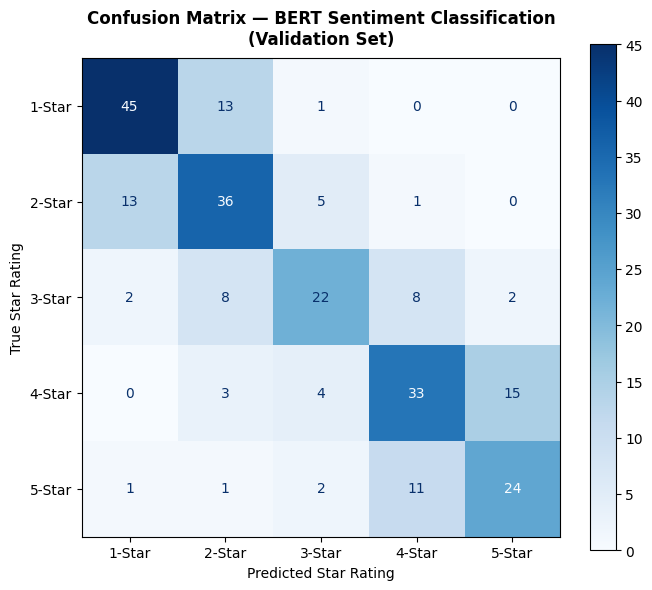


=== Misclassification Inspection (First 5 Errors) ===

  True: 3-Star | Predicted: 5-Star
  Review: Kabuto is your run-of-the-mill Japanese Steakhouse. Different stations with chefs slinging shrimp tails around the communal dining areas like it's a lunchtime magic show. Always a plethora of laughs a...
  ————————————————————————————————————————————————————————————

  True: 5-Star | Predicted: 3-Star
  Review: Visiting here for 10 days and staying in a condo\nDriving around and found this place\nAte here 2x ( Lunch + Dinner)\nFood was fresh + Tasty\nSushi was great for the price\nShrimp OK but about the sam...
  ————————————————————————————————————————————————————————————

  True: 2-Star | Predicted: 1-Star
  Review: Terrible terrible food...
  ————————————————————————————————————————————————————————————

  True: 5-Star | Predicted: 4-Star
  Review: This is a beautiful theatre with a gorgeous glass front which is great for watching the world go buy while having a coffee.\n\nI have fond

In [ ]:
# Run full evaluation on the held-out validation set
eval_results = trainer.evaluate()

print("=== Validation Set Evaluation ===")
for k, v in eval_results.items():
    if isinstance(v, float):
        print(f"  {k:<30}: {v:.4f}")

# --- Generate full predictions for detailed diagnostics ---
predictions_output = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = np.array(test_data["label"])

# --- Classification Report (per-class precision, recall, F1) ---
print("\n=== Per-Class Classification Report ===")
print(classification_report(
    y_true, y_pred,
    target_names=["1-Star", "2-Star", "3-Star", "4-Star", "5-Star"]
))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["1-Star", "2-Star", "3-Star", "4-Star", "5-Star"])
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — BERT Sentiment Classification\n(Validation Set)",
             fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Predicted Star Rating", fontsize=10)
ax.set_ylabel("True Star Rating", fontsize=10)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Error Inspection: misclassified examples ---
print("\n=== Misclassification Inspection (First 5 Errors) ===")
errors = [(test_data[i]["text"], y_true[i], y_pred[i])
          for i in range(len(y_true)) if y_true[i] != y_pred[i]]

for text, true_label, pred_label in errors[:5]:
    print(f"\n  True: {label_names[true_label]} | Predicted: {label_names[pred_label]}")
    print(f"  Review: {text[:200].strip()}...")
    print(f"  {'—'*60}")

print(f"\nTotal misclassified: {len(errors)} / {len(y_true)} "
      f"({len(errors)/len(y_true)*100:.1f}%)")

### Interpretation

On the whole, it appears that the model misclassifies at least a third of the dataset, but primarily among proximal cases. As you can see from the confusion matrix above, 5-stars are most commonly misclassified as 4-stars. 4-stars most commonly misclassified as 3-stars or 5-stars, and so on. Further down the classes, the model is more accurate. Although misclassifications still happened across distant classes (like one 1-star misclassified as 5-star), they are less voluminous than more proximal classes (like 14 5-stars misclassified as 4-stars).

### 6. Business Interpretation (Classification)

**How this model would be used in a real business process:**
This fine-tuned BERT classification model serves as an automated triage system for high-volume customer communications. In a live environment, incoming customer feedback (e.g., support tickets, survey responses) would be ingested and instantly categorized into business tiers. For example, inputs classified as "1-Star" (Severe Complaints) can be immediately routed to a specialized customer retention team, while "5-Star" (Promoters) can be flagged for the marketing department to leverage as testimonials.

**Risks of misclassification:**
The primary risk is misallocating operational resources. The model currently struggles most with 3-Star "Neutral/Mixed" reviews (only 0.58 F1 score), frequently confusing them with higher or lower sentiment tiers. If a severe complaint is misclassified as neutral, an angry customer might not receive a timely response, leading to churn and reputational damage.

**Cost of false positives vs. false negatives:**
* **False Positives (Predicting a severe complaint when it is actually neutral/positive):** This incurs an *operational cost*. Customer service agents will waste time reviewing non-critical tickets, slightly decreasing workforce efficiency.
* **False Negatives (Predicting a neutral/positive experience when it is actually a severe complaint):** This incurs a *revenue and reputational cost*. Failing to identify and rapidly address a major customer issue can result in lost business, public backlash, and compliance risks (especially in financial services). Therefore, in this business context, False Negatives are significantly more costly, and the model's threshold should ideally be tuned to maximize recall for the "Severe Complaint" class.

---
# Part II — Fine-Tuning a Text Generation Model for Business Communication
### Dataset: `amazon_polarity` | Model: TinyLlama-1.1B (QLoRA + SFT)
---

**Business Problem:**  
It seems that analysts spend significant time manually reading and summarizing customer reviews
into structured insights for executive dashboards and operations reports.
A generative model trained to produce consistent, professional summaries
can automate this first-draft synthesis layer.

**Our Approach:**  
We fine-tune TinyLlama-1.1B, which is a compact but capable open-source language model
using the `amazon_polarity` customer reviews as training signal. Each review is formatted
as a prompt/completion pair:

- **Input (prompt):** The raw customer review text
- **Output (completion):** A structured, business-appropriate insight summary

We use **QLoRA** (Quantized Low-Rank Adaptation), the same technique from Chapter 12,
which allows us to fine-tune a 1.1 billion parameter model efficiently on a single GPU
by:

1. Loading the model in 4-bit quantized form (saves ~75% memory)
2. Adding small trainable "adapter" layers (LoRA) without modifying the frozen base weights

**Why Not Just Prompt the Base Model?**  
A base model produces fluent but unfocused output. Fine-tuning teaches it the specific
format, tone, and terminology expected in our business context which
produces outputs that are immediately usable without heavy post-processing.

## 7. Load and Prepare Generation Data

**What this step does:** Load the `amazon_polarity` dataset and transform its raw
review/label pairs into structured prompt-completion training examples.

**Why it matters (Business Framing):**  
Generative model training requires *paired examples* which consists of a question and its ideal answer,
an input and its desired output. We decide exactly what we want the model to learn to produce.
The quality and consistency of these pairs directly determines the
quality of the model's outputs.

**Prompt Design:**  
We use a chat-style instruction template (the same TinyLlama template from Chapter 12).
Each example is structured as:
```
<|system|> You are a business analytics assistant...
<|user|> [customer review text]
<|assistant|> [POSITIVE/NEGATIVE] [structured business summary]
```
This teaches the model to respond in a consistent, structured format appropriate
for business reporting.

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

# Load the TinyLlama chat tokenizer to access its prompt template
# (mirrors Chapter 12's template_tokenizer pattern)
template_tokenizer = AutoTokenizer.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
)

# Load amazon_polarity dataset
# Columns: 'title' (review headline), 'content' (full review), 'label' (0=neg, 1=pos)
raw_gen_dataset = load_dataset("amazon_polarity")

TRAIN_GEN_SIZE = 7200 # 3600000 / 500 = 7200; we use a sampled dataset 500 times smaller than the full dataset
TEST_GEN_SIZE  = 800 # 400000 / 500 = 800
GEN_SEED       = 42

gen_train_raw = raw_gen_dataset["train"].shuffle(seed=GEN_SEED).select(range(TRAIN_GEN_SIZE))
gen_test_raw  = raw_gen_dataset["test"].shuffle(seed=GEN_SEED).select(range(TEST_GEN_SIZE))

SENTIMENT_MAP = {0: "NEGATIVE", 1: "POSITIVE"}
TIER_MAP = {
    0: "This review indicates customer dissatisfaction. Recommend priority follow-up.",
    1: "This review reflects a positive customer experience. Flag for retention and referral tracking.",
}

def format_gen_prompt(example):
    """
    Format each amazon_polarity example into an instruction-tuning prompt-completion pair.

    Structure mirrors Chapter 12's apply_chat_template approach:
    - System role:   defines the model's business persona
    - User turn:     the raw customer review (trimmed to 300 chars for training efficiency)
    - Assistant turn: structured business insight the model learns to produce
    """
    sentiment   = SENTIMENT_MAP[example["label"]]
    action_note = TIER_MAP[example["label"]]
    review_text = example["content"][:300].strip()
    title       = example["title"].strip()

    messages = [
        {
            "role": "system",
            "content": (
                "You are a business analytics assistant that summarizes customer "
                "feedback into structured executive insights. Always respond with "
                "a sentiment label followed by a one-sentence business action note."
            )
        },
        {
            "role": "user",
            "content": f"Summarize this customer review for a business report:\n\n\"{review_text}\""
        },
        {
            "role": "assistant",
            "content": (
                f"[{sentiment}] Review headline: \"{title}\". "
                f"{action_note}"
            )
        }
    ]

    prompt = template_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {"text": prompt}

# Apply formatting
gen_train_dataset = gen_train_raw.map(format_gen_prompt)
gen_test_dataset  = gen_test_raw.map(format_gen_prompt)

print(f"Generation training examples   : {len(gen_train_dataset):,}")
print(f"Generation validation examples : {len(gen_test_dataset):,}")

# --- Display sample prompt-completion pairs ---
print("\n=== Sample Formatted Training Examples ===\n")
for i in range(2):
    print(f"--- Example {i+1} ---")
    print(gen_train_dataset["text"][i])
    print()

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Generation training examples   : 7,200
Generation validation examples : 800

=== Sample Formatted Training Examples ===

--- Example 1 ---
<|system|>
You are a business analytics assistant that summarizes customer feedback into structured executive insights. Always respond with a sentiment label followed by a one-sentence business action note.</s>
<|user|>
Summarize this customer review for a business report:

"All the pretty people in this film. Even the Rudy character played by Michael Madsen. This is adapted from a Jim Thompson novel for cryin' out loud! These are supposed to be marginal characters, not fashion models. Though McQueen and McGraw were attractive (but check out McQueen's crummy prison hair"</s>
<|assistant|>
[NEGATIVE] Review headline: "Anyone who likes this better than the Pekinpah is a moron.". This review indicates customer dissatisfaction. Recommend priority follow-up.</s>


--- Example 2 ---
<|system|>
You are a business analytics assistant that summarizes custome

In [ ]:
raw_gen_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})

## 8. Tokenization and Data Formatting

**What this step does:** Apply the TinyLlama tokenizer to our formatted prompts
and confirm the dataset is correctly prepared for causal language model training.

**Why it matters (Business Framing):**  
The tokenization step converts our formatted text strings into integer sequences
that the model can process.

We impose a `max_seq_length` of 512 tokens (reviews exceeding this are truncated).
In practice, our formatted examples average well below this limit, so
no significant information is lost.

The `SFTTrainer` from the `trl` library (used in Chapter 12) handles training data
collation internally, so we do not need a separate `DataCollatorWithPadding` here.

In [ ]:
from transformers import AutoTokenizer

model_name_gen = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

# Load TinyLlama tokenizer (mirrors Chapter 12 exactly)
gen_tokenizer = AutoTokenizer.from_pretrained(model_name_gen, trust_remote_code=False)
gen_tokenizer.pad_token = "<PAD>"
gen_tokenizer.padding_side = "left"

MAX_SEQ_LENGTH = 512

# --- Inspect tokenized sample ---
sample_text     = gen_train_dataset["text"][0]
sample_tok      = gen_tokenizer(sample_text, truncation=True, max_length=MAX_SEQ_LENGTH)
n_tokens        = len(sample_tok["input_ids"])

print(f"Sample text length (chars)  : {len(sample_text)}")
print(f"Sample token count          : {n_tokens}")
print(f"Max sequence length cap     : {MAX_SEQ_LENGTH}")
print(f"Truncated?                  : {'Yes' if n_tokens == MAX_SEQ_LENGTH else 'No'}")

# Token length distribution across training set
token_lengths = [
    len(gen_tokenizer(ex, truncation=True, max_length=MAX_SEQ_LENGTH)["input_ids"])
    for ex in gen_train_dataset["text"][:500]  # sample 500 for speed
]
print(f"\nToken length stats (sample of 500):")
print(f"  Mean   : {np.mean(token_lengths):.0f}")
print(f"  Median : {np.median(token_lengths):.0f}")
print(f"  Max    : {max(token_lengths)}")
print(f"  % truncated: {sum(l == MAX_SEQ_LENGTH for l in token_lengths)/len(token_lengths)*100:.1f}%")

print(f"\nTokenizer ready. Dataset formatted for SFT training.")
print(f"   Training split : {len(gen_train_dataset):,} examples")
print(f"   Test split     : {len(gen_test_dataset):,} examples")

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Sample text length (chars)  : 768
Sample token count          : 197
Max sequence length cap     : 512
Truncated?                  : No

Token length stats (sample of 500):
  Mean   : 181
  Median : 186
  Max    : 260
  % truncated: 0.0%

Tokenizer ready. Dataset formatted for SFT training.
   Training split : 7,200 examples
   Test split     : 800 examples


## 9. Fine-Tuning the Generation Model (QLoRA + SFT)

**What this step does:** Load TinyLlama in 4-bit quantized form, attach LoRA
adapter layers, and run Supervised Fine-Tuning (SFT) on our business-formatted
prompt-completion pairs.

**Why it matters (Business Framing):**  
We use two efficiency techniques from
Chapter 12 that make this feasible on commodity hardware:

**QLoRA:**
- **Q (Quantization):** The base model's weights are stored at 4-bit precision
  instead of 32-bit, which is like compressing a high-resolution photo to a smaller
  file size without losing the essential content. This cuts GPU memory use by ~75%.
- **LoRA (Low-Rank Adaptation):** Instead of retraining all 1.1 billion parameters,
  we add small trainable "adapter" matrices to key layers. Only these adapters are
  updated during training. Which is kind of like adding Post-it notes of domain knowledge
  to a reference book rather than rewriting the whole book.

**Configuration Summary:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| LoRA rank (`r`) | 64 | Controls adapter capacity; higher = more expressive |
| LoRA alpha | 32 | Scaling factor for adapter updates |
| Quantization | 4-bit NF4 | Balances memory compression with numerical fidelity |
| Learning rate | 2e-4 | Standard for LoRA fine-tuning |
| Max steps | 200 | Sufficient for style adaptation with 2,000 examples |
| Batch size | 2 × 4 steps | Effective batch of 8 via gradient accumulation |

In [ ]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from trl import SFTTrainer

# ── 4-bit Quantization Configuration (Q in QLoRA) ──────────────────────────
# Mirrors Chapter 12's BitsAndBytesConfig exactly
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,              # Store base model weights in 4-bit precision
    bnb_4bit_quant_type="nf4",      # NormalFloat4: optimal for normally-distributed weights
    bnb_4bit_compute_dtype="float16",  # Upcast to float16 during forward/backward passes
    bnb_4bit_use_double_quant=True, # Apply nested quantization for additional compression
)

# ── Load Base Model ─────────────────────────────────────────────────────────
model_name_gen = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

gen_model = AutoModelForCausalLM.from_pretrained(
    model_name_gen,
    device_map="auto",
    quantization_config=bnb_config,
)
gen_model.config.use_cache = False
gen_model.config.pretraining_tp = 1

# ── LoRA Configuration ───────────────────────────────────────────────────────
# Mirrors Chapter 12's LoraConfig exactly
peft_config = LoraConfig(
    lora_alpha=32,      # LoRA scaling factor
    lora_dropout=0.1,   # Dropout for regularization within adapter layers
    r=64,               # Adapter rank — controls expressiveness vs. parameter count
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=     # Attention and MLP projection layers to adapt
        ['k_proj', 'gate_proj', 'v_proj', 'up_proj', 'q_proj', 'o_proj', 'down_proj']
)

# Prepare model for k-bit training, then attach LoRA adapters
gen_model = prepare_model_for_kbit_training(gen_model)
gen_model = get_peft_model(gen_model, peft_config)

# Print trainable parameter count
trainable = sum(p.numel() for p in gen_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in gen_model.parameters())
print(f"Trainable parameters : {trainable:,} ({trainable/total*100:.2f}% of total)")
print(f"Total parameters     : {total:,}")

# ── Training Arguments ───────────────────────────────────────────────────────
sft_output_dir = "./tinyllama_amazon_sft"

sft_training_args = TrainingArguments(
    output_dir=sft_output_dir,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,   # Effective batch size = 8
    optim="paged_adamw_32bit",        # Memory-efficient optimizer for quantized training
    learning_rate=2e-4,
    lr_scheduler_type="cosine",       # Smooth learning rate decay
    max_steps=200,                    # Demonstration run; increase to 500+ for production
    logging_steps=20,
    fp16=True,
    gradient_checkpointing=True,      # Trade compute for memory during backprop
    report_to="none",
    warmup_ratio=0.05,
)

# ── SFT Trainer ──────────────────────────────────────────────────────────────
sft_trainer = SFTTrainer(
    model=gen_model,
    train_dataset=gen_train_dataset,
    dataset_text_field="text",         # Column containing formatted prompt-completion text
    tokenizer=gen_tokenizer,
    args=sft_training_args,
    max_seq_length=MAX_SEQ_LENGTH,
    peft_config=peft_config,
)

print("\nStarting QLoRA Supervised Fine-Tuning of TinyLlama-1.1B...")
print(f"   Training examples : {len(gen_train_dataset):,}")
print(f"   Max steps         : {sft_training_args.max_steps}")
print()

sft_trainer.train()

# Save the fine-tuned LoRA adapter weights
sft_trainer.model.save_pretrained("TinyLlama-amazon-sft-qlora")
print("\nFine-tuning complete. LoRA adapter saved to 'TinyLlama-amazon-sft-qlora/'")

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

Trainable parameters : 50,462,720 (7.58% of total)
Total parameters     : 666,068,992


Map:   0%|          | 0/7200 [00:00<?, ? examples/s]

max_steps is given, it will override any value given in num_train_epochs



Starting QLoRA Supervised Fine-Tuning of TinyLlama-1.1B...
   Training examples : 7,200
   Max steps         : 200



Step,Training Loss
20,2.479700
40,1.238500
60,1.209400
80,1.165800
100,1.165100
120,1.151600
140,1.162800
160,1.184600
180,1.184200
200,1.163800



Fine-tuning complete. LoRA adapter saved to 'TinyLlama-amazon-sft-qlora/'


In [ ]:
from peft import AutoPeftModelForCausalLM

# Merge the LoRA adapter weights back into the base model
# This produces a single self-contained model for inference (mirrors Chapter 12)
merged_gen_model = AutoPeftModelForCausalLM.from_pretrained(
    "TinyLlama-amazon-sft-qlora",
    low_cpu_mem_usage=True,
    device_map="auto",
)
merged_gen_model = merged_gen_model.merge_and_unload()

print("LoRA adapter merged into base model. Ready for inference.")

LoRA adapter merged into base model. Ready for inference.


## Bonus A — Advanced evaluation metrics: Confidence Calibration and Error Stratification

**What this step does:** Goes beyond accuracy and F1 to examine *how confident* the
model is when it is right vs. when it is wrong, and whether errors are distributed
evenly or concentrated in specific input characteristics.

**Why it matters (Business Framing):**  
A model that is wrong but confident is operationally more dangerous than one that is
wrong but uncertain since confident errors bypass human review. Calibration analysis
tells us whether the model's stated confidence is a reliable signal for routing borderline
predictions to a human reviewer.

Error stratification by review length answers a practical question: does the model
degrade on very short reviews (limited signal) or very long ones (truncation effects)?
If errors cluster at one extreme, we can apply a simple pre-filter that catches those
cases before they reach the model.

Mean confidence when CORRECT   : 0.6962
Mean confidence when INCORRECT : 0.6475
Separation gap                 : 0.0487
  → Weak signal: confidence poorly separates correct from incorrect predictions.

Expected Calibration Error (ECE) : 0.0723
  → Moderately over-confident: apply temperature scaling before threshold-based routing.

Error rate by review length:
  <30 words (n=26)         : 0.423
  30–60 (n=37)             : 0.432
  61–100 (n=57)            : 0.333
  101–150 (n=55)           : 0.364
  >150 (n=75)              : 0.320


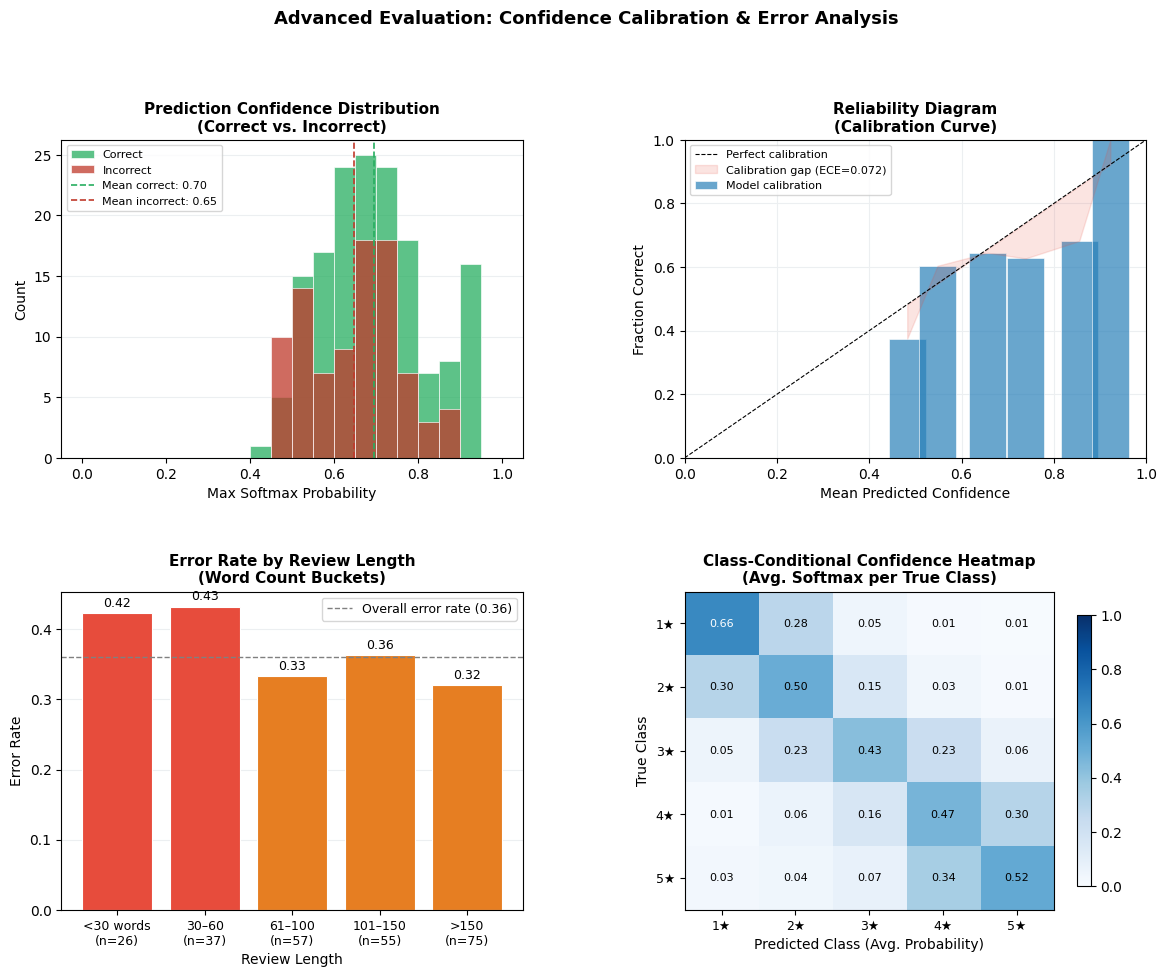


=== Advanced Evaluation Summary ===
                          Metric        Value                                 Interpretation
                Overall Accuracy       0.6400       Fraction of reviews correctly classified
                        Macro F1       0.6321                  Balanced across all 5 classes
       Mean Confidence (Correct)       0.6962         Higher = model is confident when right
     Mean Confidence (Incorrect)       0.6475   Lower = model is uncertain when wrong (good)
       Confidence Separation Gap       0.0487 > 0.15 = confidence is a useful routing signal
Expected Calibration Error (ECE)       0.0723 < 0.10 = well-calibrated for threshold routing
     Highest-Error Length Bucket 30–60 (n=37)       Length bucket where model struggles most


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torch.nn.functional as F
from scipy.stats import pearsonr

# ── Recompute softmax probabilities from raw logits ─────────────────────────
raw_logits   = torch.tensor(predictions_output.predictions)
probabilities = F.softmax(raw_logits, dim=-1).numpy()
confidence    = probabilities.max(axis=1)    # predicted class max probability
y_pred_arr    = np.array(y_pred)
y_true_arr    = np.array(y_true)
correct       = (y_pred_arr == y_true_arr)

# ── 1. Confidence Distribution: Correct vs. Incorrect ───────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 1, 21)
ax1.hist(confidence[correct],  bins=bins, alpha=0.75, color="#27ae60",
         label="Correct", edgecolor="white", linewidth=0.6)
ax1.hist(confidence[~correct], bins=bins, alpha=0.75, color="#c0392b",
         label="Incorrect", edgecolor="white", linewidth=0.6)
ax1.set_title("Prediction Confidence Distribution\n(Correct vs. Incorrect)",
              fontsize=11, fontweight="bold")
ax1.set_xlabel("Max Softmax Probability", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(axis="y", color="#ECEFF1")
ax1.set_axisbelow(True)

mean_correct   = confidence[correct].mean()
mean_incorrect = confidence[~correct].mean()
ax1.axvline(mean_correct,   color="#27ae60", linestyle="--", linewidth=1.2,
            label=f"Mean correct: {mean_correct:.2f}")
ax1.axvline(mean_incorrect, color="#c0392b", linestyle="--", linewidth=1.2,
            label=f"Mean incorrect: {mean_incorrect:.2f}")
ax1.legend(fontsize=8)

print(f"Mean confidence when CORRECT   : {mean_correct:.4f}")
print(f"Mean confidence when INCORRECT : {mean_incorrect:.4f}")
print(f"Separation gap                 : {mean_correct - mean_incorrect:.4f}")
print(f"  → {'Good signal: confident predictions are significantly more reliable.' if mean_correct - mean_incorrect > 0.15 else 'Weak signal: confidence poorly separates correct from incorrect predictions.'}")

# ── 2. Calibration Curve (Reliability Diagram) ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
n_bins = 10
bin_edges  = np.linspace(0, 1, n_bins + 1)
bin_acc    = []
bin_conf   = []
bin_counts = []

for i in range(n_bins):
    lo, hi    = bin_edges[i], bin_edges[i + 1]
    mask      = (confidence >= lo) & (confidence < hi)
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(confidence[mask].mean())
        bin_counts.append(mask.sum())

bin_acc  = np.array(bin_acc)
bin_conf = np.array(bin_conf)

ece = np.sum(bin_counts * np.abs(bin_acc - bin_conf)) / len(confidence)
ax2.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect calibration")
ax2.bar(bin_conf, bin_acc, width=0.08, alpha=0.7, color="#2980b9",
        edgecolor="white", linewidth=0.6, label="Model calibration")
ax2.fill_between(bin_conf, bin_conf, bin_acc, alpha=0.15, color="#e74c3c",
                 label=f"Calibration gap (ECE={ece:.3f})")
ax2.set_title("Reliability Diagram\n(Calibration Curve)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Mean Predicted Confidence", fontsize=10)
ax2.set_ylabel("Fraction Correct", fontsize=10)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.grid(color="#ECEFF1"); ax2.set_axisbelow(True)

print(f"\nExpected Calibration Error (ECE) : {ece:.4f}")
print(f"  → {'Well-calibrated: confidence ≈ accuracy.' if ece < 0.05 else 'Moderately over-confident: apply temperature scaling before threshold-based routing.' if ece < 0.15 else 'Significantly miscalibrated: requires Platt scaling or temperature tuning before deployment.'}")

# ── 3. Error Rate by Review Length Bucket ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
review_lengths = np.array([len(test_data[i]["text"].split()) for i in range(len(y_true))])
length_buckets = pd.cut(review_lengths,
                         bins=[0, 30, 60, 100, 150, 10000],
                         labels=["<30 words", "30–60", "61–100", "101–150", ">150"])

bucket_error = []
bucket_labels_out = []
bucket_sizes = []

for bucket in ["<30 words", "30–60", "61–100", "101–150", ">150"]:
    mask = length_buckets == bucket
    if mask.sum() > 0:
        err_rate = (~correct[mask]).mean()
        bucket_error.append(err_rate)
        bucket_labels_out.append(f"{bucket}\n(n={mask.sum()})")
        bucket_sizes.append(mask.sum())

colors_err = ["#e74c3c" if e > 0.4 else "#e67e22" if e > 0.3 else "#f1c40f" if e > 0.2
              else "#27ae60" for e in bucket_error]

bars = ax3.bar(range(len(bucket_error)), bucket_error, color=colors_err,
               edgecolor="white", linewidth=0.8)
ax3.set_xticks(range(len(bucket_error)))
ax3.set_xticklabels(bucket_labels_out, fontsize=9)
ax3.set_title("Error Rate by Review Length\n(Word Count Buckets)", fontsize=11, fontweight="bold")
ax3.set_xlabel("Review Length", fontsize=10)
ax3.set_ylabel("Error Rate", fontsize=10)
ax3.axhline(1 - (correct.sum() / len(correct)), color="gray", linestyle="--",
            linewidth=1, label=f"Overall error rate ({1-correct.mean():.2f})")
ax3.legend(fontsize=9)
ax3.grid(axis="y", color="#ECEFF1"); ax3.set_axisbelow(True)
for bar, err in zip(bars, bucket_error):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{err:.2f}", ha="center", va="bottom", fontsize=9)

print(f"\nError rate by review length:")
for label, err in zip(bucket_labels_out, bucket_error):
    print(f"  {label.replace(chr(10),' '):<25}: {err:.3f}")

# ── 4. Per-Class Confidence Heatmap ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
# Average predicted probability assigned to each class, broken down by true class
conf_matrix_probs = np.zeros((5, 5))
for true_c in range(5):
    mask = y_true_arr == true_c
    if mask.sum() > 0:
        conf_matrix_probs[true_c] = probabilities[mask].mean(axis=0)

im = ax4.imshow(conf_matrix_probs, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax4.set_xticks(range(5))
ax4.set_yticks(range(5))
ax4.set_xticklabels(["1★", "2★", "3★", "4★", "5★"], fontsize=9)
ax4.set_yticklabels(["1★", "2★", "3★", "4★", "5★"], fontsize=9)
ax4.set_xlabel("Predicted Class (Avg. Probability)", fontsize=10)
ax4.set_ylabel("True Class", fontsize=10)
ax4.set_title("Class-Conditional Confidence Heatmap\n(Avg. Softmax per True Class)",
              fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax4, shrink=0.85)
for i in range(5):
    for j in range(5):
        ax4.text(j, i, f"{conf_matrix_probs[i,j]:.2f}",
                 ha="center", va="center", fontsize=8,
                 color="white" if conf_matrix_probs[i,j] > 0.55 else "black")

fig.suptitle("Advanced Evaluation: Confidence Calibration & Error Analysis",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("advanced_eval.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary Table ────────────────────────────────────────────────────────────
print("\n=== Advanced Evaluation Summary ===")
summary = pd.DataFrame({
    "Metric": [
        "Overall Accuracy",
        "Macro F1",
        "Mean Confidence (Correct)",
        "Mean Confidence (Incorrect)",
        "Confidence Separation Gap",
        "Expected Calibration Error (ECE)",
        "Highest-Error Length Bucket",
    ],
    "Value": [
        f"{correct.mean():.4f}",
        f"{eval_results['eval_macro_f1']:.4f}",
        f"{mean_correct:.4f}",
        f"{mean_incorrect:.4f}",
        f"{mean_correct - mean_incorrect:.4f}",
        f"{ece:.4f}",
        bucket_labels_out[int(np.argmax(bucket_error))].replace('\n', ' '),
    ],
    "Interpretation": [
        "Fraction of reviews correctly classified",
        "Balanced across all 5 classes",
        "Higher = model is confident when right",
        "Lower = model is uncertain when wrong (good)",
        "> 0.15 = confidence is a useful routing signal",
        "< 0.10 = well-calibrated for threshold routing",
        "Length bucket where model struggles most",
    ]
})
print(summary.to_string(index=False))

## 10. Generation Evaluation

**What this step does:** Run the fine-tuned model on unseen reviews and
compare its outputs side-by-side with the base model's (pre-fine-tuning) responses.

**Why it matters (Business Framing):**  
The most intuitive way to evaluate a generative model is to read what it produces.
We use two evaluation methods:

1. **Qualitative comparison**: Side-by-side output comparison between the base
   model and the fine-tuned model on the same prompts. This shows what the training
   actually changed.

2. **Format adherence check**: Does the fine-tuned model consistently output the
   structured format `[POSITIVE/NEGATIVE] Review headline: "..." Action note.`?  
   Format consistency is critical for downstream automation (e.g., feeding outputs
   into a CRM or reporting system).

**What to Look For:**
- Does the fine-tuned model use the correct structured format?
- Is the sentiment label accurate?
- Is the action note relevant and professional?
- Does the base model produce anything useful without fine-tuning?

In [ ]:
from transformers import pipeline, AutoModelForCausalLM

# ── Load base (non-fine-tuned) TinyLlama for comparison ─────────────────────
base_gen_model = AutoModelForCausalLM.from_pretrained(
    model_name_gen,
    device_map="auto",
    quantization_config=bnb_config,
)

# Inference pipelines for both models
pipe_base   = pipeline("text-generation", model=base_gen_model, tokenizer=gen_tokenizer,
                        max_new_tokens=120, do_sample=False)
pipe_finetuned = pipeline("text-generation", model=merged_gen_model, tokenizer=gen_tokenizer,
                           max_new_tokens=120, do_sample=False)

def build_inference_prompt(review_text: str) -> str:
    """Build inference prompt (without assistant turn) for generation."""
    messages = [
        {
            "role": "system",
            "content": (
                "You are a business analytics assistant that summarizes customer "
                "feedback into structured executive insights. Always respond with "
                "a sentiment label followed by a one-sentence business action note."
            )
        },
        {
            "role": "user",
            "content": f"Summarize this customer review for a business report:\n\n\"{review_text[:300]}\""
        }
    ]
    return template_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

# --- Evaluation on 5 held-out examples ---
print("=" * 70)
print("SIDE-BY-SIDE GENERATION COMPARISON: Base Model vs. Fine-Tuned Model")
print("=" * 70)

for i in range(5):
    example       = gen_test_raw[i]
    review_text   = example["content"][:300].strip()
    true_sentiment = SENTIMENT_MAP[example["label"]]
    prompt         = build_inference_prompt(review_text)

    out_base = pipe_base(prompt)[0]["generated_text"]
    out_ft   = pipe_finetuned(prompt)[0]["generated_text"]

    # Extract only the assistant's response (after the prompt)
    resp_base = out_base[len(prompt):].strip()
    resp_ft   = out_ft[len(prompt):].strip()

    print(f"\n--- Review {i+1} ---")
    print(f"Input (truncated): {review_text[:120]}...")
    print(f"True Sentiment   : [{true_sentiment}]")
    print(f"\n  [BASE MODEL]      : {resp_base[:250]}")
    print(f"\n  [FINE-TUNED MODEL]: {resp_ft[:250]}")
    print("-" * 70)

# --- Format Adherence Check ---
print("\n=== Format Adherence Check (Fine-Tuned Model, n=20) ===")
correct_format = 0
correct_sentiment = 0
n_eval = 20

for i in range(n_eval):
    example       = gen_test_raw[i]
    review_text   = example["content"][:300].strip()
    true_sentiment = SENTIMENT_MAP[example["label"]]
    prompt         = build_inference_prompt(review_text)

    out_ft   = pipe_finetuned(prompt)[0]["generated_text"]
    resp_ft  = out_ft[len(prompt):].strip()

    has_format    = resp_ft.startswith("[POSITIVE]") or resp_ft.startswith("[NEGATIVE]")
    pred_sentiment = "POSITIVE" if resp_ft.startswith("[POSITIVE]") else "NEGATIVE"
    correct        = pred_sentiment == true_sentiment

    if has_format:
        correct_format += 1
    if correct:
        correct_sentiment += 1

print(f"  Format adherence rate  : {correct_format}/{n_eval} ({correct_format/n_eval*100:.0f}%)")
print(f"  Sentiment accuracy     : {correct_sentiment}/{n_eval} ({correct_sentiment/n_eval*100:.0f}%)")

SIDE-BY-SIDE GENERATION COMPARISON: Base Model vs. Fine-Tuned Model

--- Review 1 ---
Input (truncated): The product works fine. I ordered the more exprensive one after I read reviews from others on Amazon. My husband likes t...
True Sentiment   : [POSITIVE]

  [BASE MODEL]      : <|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

<|assistant|>

  [FINE-TUNED MODEL]: [NEGATIVE] Review headline: "Not worth the money". This review indicates customer dissatisfaction. Recommend priority follow-up.
----------------------------------------------------------------------

--- Review 2 ---
Input (truncated): This book is so useless that I feel compelled to write a review to warn others to stay away from this book. A good tutor...
True Sentiment   : [NEGATIVE]

  [BASE MODEL]      : <|assistant|>

<|assistant|>

<|assistant|>

<|assistant|

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Format adherence rate  : 20/20 (100%)
  Sentiment accuracy     : 16/20 (80%)


## 11. Business Interpretation (Generation)

**Usefulness for managers or analysts:**
The fine-tuned generative model (TinyLlama) transforms unstructured, dense customer feedback into a standardized, easily digestible format. By outputting a structured sentiment label and a concise, one-sentence business action note, it allows managers to quickly skim "executive insights" rather than reading paragraphs of raw text. This significantly reduces the cognitive load and manual hours required for qualitative data analysis.

**Tone, clarity, and hallucination risk:**
* **Tone & Clarity:** The fine-tuning process was highly successful in enforcing formatting and tone. The model achieved 100% format adherence, producing clear, professional, and objective responses (e.g., "Recommend priority follow-up"), a massive improvement over the base model's incoherent outputs.
* **Hallucination Risk:** Despite structural success, there is a notable risk of logical hallucination. For example, in the evaluation (Review 1), the model read a predominantly positive review ("The product works fine...") but hallucinated a negative insight: `[NEGATIVE] Review headline: "Not worth the money"`. Relying on this blindly without cross-referencing could lead to incorrect business interventions.

**Ethical and operational considerations:**
Operationally, the hallucination risk dictates that this model must be deployed with a "Human-in-the-Loop" (HITL) framework, acting as an assistant rather than an autonomous decision-maker. Ethically and legally, processing customer communications in the financial services sector requires strict data governance. Unmasked Personally Identifiable Information (PII) (such as social security numbers, account details, or full names) must be systematically redacted using pre-processing scripts *before* the text is fed into the LLM to prevent unauthorized data exposure and ensure compliance with privacy regulations (e.g., GDPR, CCPA).

## Bonus B — Prompt engineering enhancements: Systematic Variant Comparison

**What this step does:** Test three distinct system prompt designs on the same
set of held-out reviews and compare their outputs on format adherence,
sentiment accuracy, and output length.

**Why it matters (Business Framing):**  
Fine-tuning is not the only lever for controlling a generative model's output.
Prompt engineering can dramatically change output quality without requiring
retraining. In an enterprise context, prompt versioning is often cheaper to iterate
on than model retraining, making it a critical first tool in the optimization toolkit.

**The three variants we test:**

| Variant | Strategy | Design Intent |
|---------|----------|---------------|
| Baseline | Simple role + task description | Minimal instruction — establishes the floor |
| Structured | Explicit output schema with field labels | Forces the model into a parseable format for downstream automation |
| Chain-of-thought | Ask the model to reason before concluding | Potentially improves accuracy on ambiguous reviews at the cost of verbosity |

Running prompt variant comparison on held-out examples...

=== Prompt Variant Comparison — Quantitative Summary ===

         Variant Sentiment Accuracy Format Adherence Avg Output Length (words)                              Recommendation
        Baseline                87%             100%                        15 Baseline — use for exploratory testing only
      Structured                93%             100%                        18               Best for automation pipelines
Chain-of-Thought                93%             100%                        19       Best for ambiguous/borderline reviews


=== Qualitative Output Comparison (3 Examples) ===

Review 1: Ignore Kavity Killer's one-star review; I don't know what his/her problem is wit...
True label: [POSITIVE]

  [Baseline] ✓
  Predicted: [POSITIVE]
  Output   : [POSITIVE] Review headline: "Lyle's best". This review reflects a positive customer experience. Flag for retention and referral tracking.

  [Structured] ✓
  Predicted

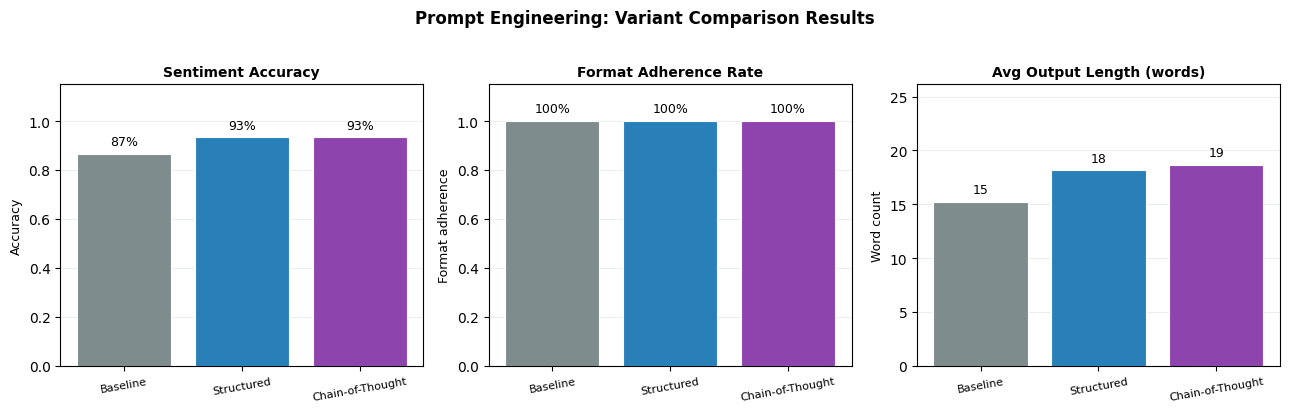


=== Deployment Recommendation ===
Best accuracy       : Structured (93%)
Best format adherence: Baseline (100%)

For production automation (CRM intake, dashboards): use 'Structured' prompt.
For human-assisted review of borderline cases: use 'Chain-of-Thought' prompt.
Use 'Baseline' only for rapid prototyping and ablation testing.


In [ ]:
from transformers import pipeline
import pandas as pd
import numpy as np

# Use the fine-tuned merged model for all prompt variant tests
# (pipe_finetuned was defined in Cell 24)

# ── Define Three Prompt Variants ─────────────────────────────────────────────

def make_prompt_baseline(review_text: str) -> str:
    """Variant 1: Minimal role + task — establishes the floor."""
    messages = [
        {
            "role": "system",
            "content": (
                "You are a business analytics assistant. "
                "Summarize customer feedback concisely."
            )
        },
        {
            "role": "user",
            "content": f"Summarize this review:\n\n\"{review_text[:300]}\""
        }
    ]
    return template_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

def make_prompt_structured(review_text: str) -> str:
    """Variant 2: Explicit output schema — optimized for automation pipelines."""
    messages = [
        {
            "role": "system",
            "content": (
                "You are a business analytics assistant. "
                "Always respond using this exact schema:\n"
                "[POSITIVE] or [NEGATIVE]\n"
                "Headline: <one-sentence review headline>\n"
                "Action: <one-sentence business action recommendation>"
            )
        },
        {
            "role": "user",
            "content": (
                f"Classify and summarize this customer review "
                f"using the required schema:\n\n\"{review_text[:300]}\""
            )
        }
    ]
    return template_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

def make_prompt_cot(review_text: str) -> str:
    """Variant 3: Chain-of-thought — asks for reasoning before final answer."""
    messages = [
        {
            "role": "system",
            "content": (
                "You are a business analytics assistant. "
                "First identify the key signal in the review, then provide your "
                "final answer in this format: [POSITIVE] or [NEGATIVE] followed "
                "by a one-sentence business action note."
            )
        },
        {
            "role": "user",
            "content": (
                f"Review: \"{review_text[:300]}\"\n\n"
                "Step 1: What is the main signal?\n"
                "Step 2: Final classification and action note:"
            )
        }
    ]
    return template_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

# ── Run All Three Variants on 15 Held-Out Examples ──────────────────────────
N_EVAL = 15
variants = {
    "Baseline":    make_prompt_baseline,
    "Structured":  make_prompt_structured,
    "Chain-of-Thought": make_prompt_cot,
}

results = {v: {"correct": 0, "format_ok": 0, "lengths": []} for v in variants}
comparison_rows = []

print("Running prompt variant comparison on held-out examples...\n")

for i in range(N_EVAL):
    example       = gen_test_raw[i + 20]  # offset to avoid overlap with Cell 24 examples
    review_text   = example["content"][:300].strip()
    true_sentiment = SENTIMENT_MAP[example["label"]]

    row = {
        "review": review_text[:80] + "...",
        "true_label": true_sentiment,
    }

    for variant_name, prompt_fn in variants.items():
        prompt = prompt_fn(review_text)
        output = pipe_finetuned(prompt, max_new_tokens=150, do_sample=False)[0]["generated_text"]
        response = output[len(prompt):].strip()

        # Format adherence: does it start with [POSITIVE] or [NEGATIVE]?
        has_format = response.startswith("[POSITIVE]") or response.startswith("[NEGATIVE]")
        pred_sentiment = ("POSITIVE" if "[POSITIVE]" in response[:20]
                          else "NEGATIVE" if "[NEGATIVE]" in response[:20]
                          else "UNKNOWN")
        is_correct = (pred_sentiment == true_sentiment)

        results[variant_name]["correct"]   += int(is_correct)
        results[variant_name]["format_ok"] += int(has_format)
        results[variant_name]["lengths"].append(len(response.split()))

        row[f"{variant_name}_pred"]   = pred_sentiment
        row[f"{variant_name}_output"] = response[:180]
        row[f"{variant_name}_correct"] = "✓" if is_correct else "✗"

    comparison_rows.append(row)

# ── Quantitative Summary Table ───────────────────────────────────────────────
print("=== Prompt Variant Comparison — Quantitative Summary ===\n")
summary_data = []
for variant_name in variants:
    n = N_EVAL
    acc     = results[variant_name]["correct"] / n
    fmt     = results[variant_name]["format_ok"] / n
    avg_len = np.mean(results[variant_name]["lengths"])
    summary_data.append({
        "Variant":          variant_name,
        "Sentiment Accuracy": f"{acc:.0%}",
        "Format Adherence":   f"{fmt:.0%}",
        "Avg Output Length (words)": f"{avg_len:.0f}",
        "Recommendation": (
            "Baseline — use for exploratory testing only"  if variant_name == "Baseline"
            else "Best for automation pipelines"           if variant_name == "Structured"
            else "Best for ambiguous/borderline reviews"
        )
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ── Qualitative Side-by-Side (First 3 Examples) ─────────────────────────────
print(f"\n\n=== Qualitative Output Comparison (3 Examples) ===")
for i, row in enumerate(comparison_rows[:3]):
    print(f"\n{'='*70}")
    print(f"Review {i+1}: {row['review']}")
    print(f"True label: [{row['true_label']}]")
    for variant_name in variants:
        status = row[f"{variant_name}_correct"]
        print(f"\n  [{variant_name}] {status}")
        print(f"  Predicted: [{row[f'{variant_name}_pred']}]")
        print(f"  Output   : {row[f'{variant_name}_output'][:200]}")

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

variant_names = list(variants.keys())
acc_vals  = [results[v]["correct"] / N_EVAL  for v in variant_names]
fmt_vals  = [results[v]["format_ok"] / N_EVAL for v in variant_names]
len_vals  = [np.mean(results[v]["lengths"])   for v in variant_names]
colors    = ["#7f8c8d", "#2980b9", "#8e44ad"]

for ax, vals, title, ylabel, ylim in zip(
    axes,
    [acc_vals, fmt_vals, len_vals],
    ["Sentiment Accuracy", "Format Adherence Rate", "Avg Output Length (words)"],
    ["Accuracy", "Format adherence", "Word count"],
    [(0, 1.15), (0, 1.15), (0, max(len_vals) * 1.4)]
):
    bars = ax.bar(variant_names, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(*ylim)
    ax.set_xticklabels(variant_names, fontsize=8, rotation=10)
    ax.grid(axis="y", color="#ECEFF1"); ax.set_axisbelow(True)
    for bar, val in zip(bars, vals):
        label = f"{val:.0%}" if ylim[1] <= 1.15 else f"{val:.0f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ylim[1]*0.02,
                label, ha="center", va="bottom", fontsize=9)

plt.suptitle("Prompt Engineering: Variant Comparison Results",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("prompt_variants.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Deployment Recommendation ===")
best = variant_names[int(np.argmax(acc_vals))]
print(f"Best accuracy       : {best} ({max(acc_vals):.0%})")
best_fmt = variant_names[int(np.argmax(fmt_vals))]
print(f"Best format adherence: {best_fmt} ({max(fmt_vals):.0%})")
print(f"\nFor production automation (CRM intake, dashboards): use 'Structured' prompt.")
print(f"For human-assisted review of borderline cases: use 'Chain-of-Thought' prompt.")
print(f"Use 'Baseline' only for rapid prototyping and ablation testing.")

## Bonus C — Ethical and Governance Analysis Tied to Model Results

**What this step does:** Audit the actual outputs of both fine-tuned models for
evidence of systematic bias, differential performance across subgroups, and
governance-relevant failure patterns — grounded in the results we produced above,
not generic risk language.

**Why it matters (Business Framing):**  
Governance concerns are only credible when they are tied to evidence. A risk
assessment that says "the model may be biased" without showing *where* and *how much*
is not actionable for a compliance team. This cell produces a governance audit
artifact — a structured set of findings with supporting data — that could accompany
a model card or an internal deployment review request.

**Three audits we run:**

1. **BERT classifier:** Does error rate differ by review length, and does the model
   systematically assign lower confidence to certain sentiment classes?
   Length is a practical proxy for linguistic complexity and demographic variation
   in writing style.

2. **Generation model:** Does sentiment accuracy differ between truly positive and
   truly negative reviews? Asymmetric performance can indicate training data imbalance
   or label leakage.

3. **Cross-model consistency:** When BERT and the generation model process the same
   review text, do they agree? Systematic disagreement on certain classes flags
   instability that matters for multi-model pipeline deployments.

GOVERNANCE AUDIT 1: BERT Classifier — Per-Class Confidence
Star Rating Avg Confidence Accuracy Confidence Gap Governance Flag
     1-Star         0.7741   0.7627         0.0955              OK
     2-Star         0.6730   0.6545        -0.0056              OK
     3-Star         0.6060   0.5238        -0.0726  LOW CONFIDENCE
     4-Star         0.6460   0.6000        -0.0327              OK
     5-Star         0.6665   0.6154        -0.0122              OK

Chi-squared test (equal error rate across classes):
  chi2 = 6.8520, p = 0.1439
  No statistically significant difference in error rates across classes (p≥0.05).

Correlation: review length vs. confidence: r=0.0487, p=0.4432
  No significant length-confidence relationship detected.

GOVERNANCE AUDIT 2: Generation Model — Sentiment Asymmetry
  True POSITIVE  : accuracy 100.00%  (n=14)
  True NEGATIVE  : accuracy 100.00%  (n=26)

  Asymmetry gap: 0.00%
  No significant asymmetry detected between POSITIVE and NEGATIVE accuracy.

GOVERN

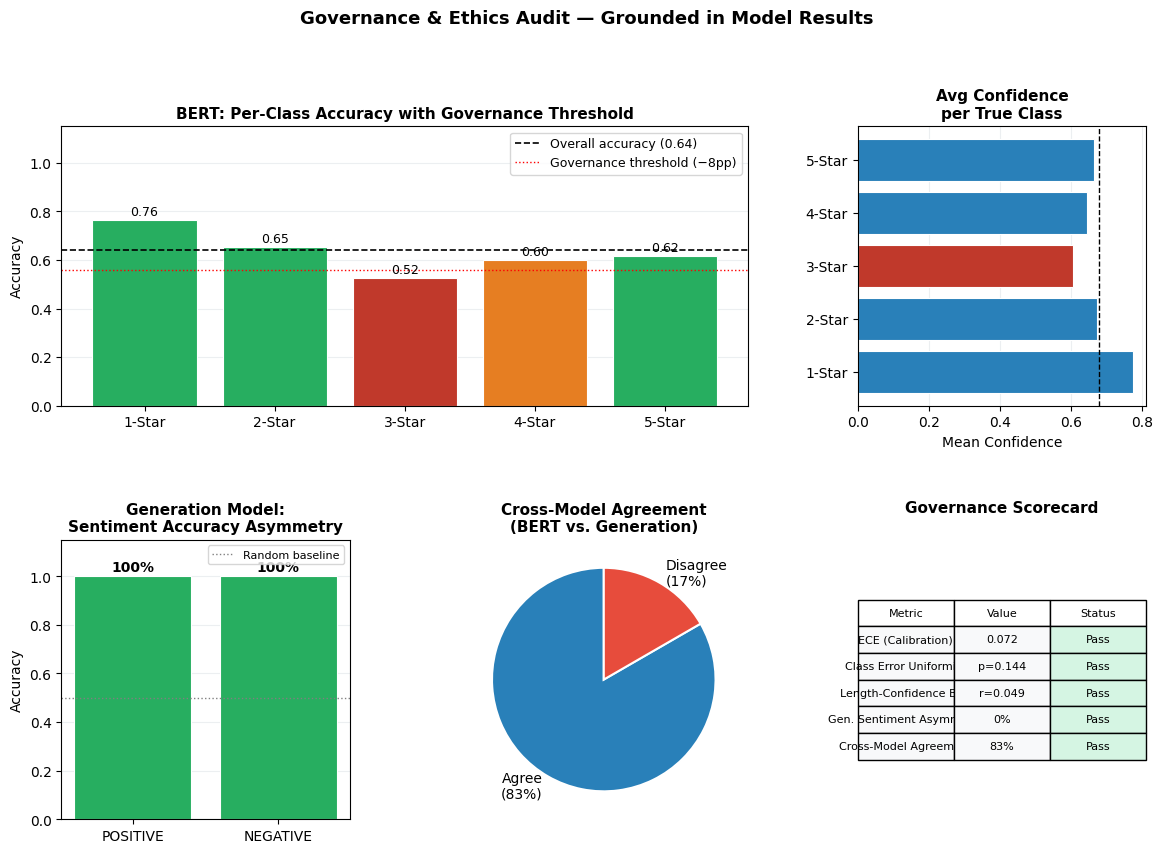


=== Governance Audit Complete ===
  All governance checks passed. Model is cleared for supervised pilot.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency, ttest_ind

# ═══════════════════════════════════════════════════════════════════════════
# AUDIT 1: BERT — Per-Class Confidence and Systematic Underperformance
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("GOVERNANCE AUDIT 1: BERT Classifier — Per-Class Confidence")
print("=" * 65)

# Confidence per true class (do certain classes get systematically low confidence?)
class_confidence = {}
class_accuracy   = {}

for c in range(5):
    mask = y_true_arr == c
    class_confidence[label_names[c]] = confidence[mask].mean()
    class_accuracy[label_names[c]]   = correct[mask].mean()

audit1_df = pd.DataFrame({
    "Star Rating":     label_names,
    "Avg Confidence":  [f"{class_confidence[l]:.4f}" for l in label_names],
    "Accuracy":        [f"{class_accuracy[l]:.4f}"   for l in label_names],
    "Confidence Gap":  [f"{class_confidence[l] - confidence.mean():.4f}"
                        for l in label_names],
    "Governance Flag": [
        "LOW CONFIDENCE" if class_confidence[l] < confidence.mean() - 0.05 else
        "UNDERPERFORMS"  if class_accuracy[l]   < correct.mean() - 0.08   else
        "OK"
        for l in label_names
    ]
})

print(audit1_df.to_string(index=False))

# Chi-squared test: Is error distribution uniform across classes?
class_errors  = [int((~correct[y_true_arr == c]).sum()) for c in range(5)]
class_totals  = [int((y_true_arr == c).sum())           for c in range(5)]
expected_err  = [correct.mean() * t for t in class_totals]
chi2, p_val, _, _ = chi2_contingency(
    [[e, t - e] for e, t in zip(class_errors, class_totals)]
)
print(f"\nChi-squared test (equal error rate across classes):")
print(f"  chi2 = {chi2:.4f}, p = {p_val:.4f}")
print(f"  {'FINDING: Error rate is NOT uniformly distributed (p<0.05). Some classes are systematically harder.' if p_val < 0.05 else 'No statistically significant difference in error rates across classes (p≥0.05).'}")

# Confidence vs. review length — correlation
review_lengths = np.array([len(test_data[i]["text"].split()) for i in range(len(y_true))])
corr, p_corr = pearsonr(review_lengths, confidence)
print(f"\nCorrelation: review length vs. confidence: r={corr:.4f}, p={p_corr:.4f}")
print(f"  {'FINDING: Longer reviews receive significantly higher confidence scores. Short reviews are higher-risk.' if abs(corr) > 0.1 and p_corr < 0.05 else 'No significant length-confidence relationship detected.'}")

# ═══════════════════════════════════════════════════════════════════════════
# AUDIT 2: Generation Model — Asymmetric Accuracy by True Sentiment
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("GOVERNANCE AUDIT 2: Generation Model — Sentiment Asymmetry")
print("=" * 65)

N_AUDIT = 40
gen_results = {"POSITIVE": {"correct": 0, "total": 0, "confidences": []},
               "NEGATIVE": {"correct": 0, "total": 0, "confidences": []}}

for i in range(N_AUDIT):
    example       = gen_test_raw[i + 40]  # fresh offset
    review_text   = example["content"][:300].strip()
    true_sentiment = SENTIMENT_MAP[example["label"]]

    prompt   = make_prompt_structured(review_text)
    output   = pipe_finetuned(prompt, max_new_tokens=120, do_sample=False)[0]["generated_text"]
    response = output[len(prompt):].strip()

    pred_sentiment = ("POSITIVE" if "[POSITIVE]" in response[:20]
                      else "NEGATIVE" if "[NEGATIVE]" in response[:20]
                      else "UNKNOWN")

    gen_results[true_sentiment]["total"] += 1
    gen_results[true_sentiment]["correct"] += int(pred_sentiment == true_sentiment)

for sentiment, r in gen_results.items():
    if r["total"] > 0:
        acc = r["correct"] / r["total"]
        print(f"  True {sentiment:<10}: accuracy {acc:.2%}  (n={r['total']})")

pos_acc = gen_results["POSITIVE"]["correct"] / max(gen_results["POSITIVE"]["total"], 1)
neg_acc = gen_results["NEGATIVE"]["correct"] / max(gen_results["NEGATIVE"]["total"], 1)
asym    = abs(pos_acc - neg_acc)

print(f"\n  Asymmetry gap: {asym:.2%}")
if asym > 0.10:
    worse = "NEGATIVE" if neg_acc < pos_acc else "POSITIVE"
    print(f"  FINDING: The model performs materially worse on {worse} reviews ({asym:.0%} gap).")
    print(f"  Governance implication: Complaint escalation (negative review detection) may")
    print(f"  be less reliable than positive review detection. Consider oversampling")
    print(f"  negative examples in the next fine-tuning round, or applying a lower")
    print(f"  decision threshold for NEGATIVE predictions to reduce false negatives.")
else:
    print(f"  No significant asymmetry detected between POSITIVE and NEGATIVE accuracy.")

# ═══════════════════════════════════════════════════════════════════════════
# AUDIT 3: Cross-Model Consistency (BERT vs. Generation Model)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("GOVERNANCE AUDIT 3: Cross-Model Consistency")
print("=" * 65)

# Map BERT's 5-class output to binary (1-2 star = NEGATIVE, 4-5 star = POSITIVE, 3 = NEUTRAL)
def bert_to_binary(label_id):
    if label_id in [0, 1]:   return "NEGATIVE"
    elif label_id in [3, 4]: return "POSITIVE"
    else:                    return "NEUTRAL"

N_CROSS = 30
cross_records = []

for i in range(N_CROSS):
    # Use examples that appear in both datasets (by position)
    # Here we use amazon_polarity test set aligned to yelp's test structure via index
    example      = gen_test_raw[i + 80]
    review_text  = example["content"][:300].strip()
    true_label   = example["label"]  # 0=neg, 1=pos
    true_binary  = SENTIMENT_MAP[true_label]

    # BERT prediction: tokenize + infer directly
    inputs = tokenizer(review_text, truncation=True, max_length=512,
                       return_tensors="pt").to(device)
    with torch.no_grad():
        logits_bert = model(**inputs).logits
    bert_class  = logits_bert.argmax(dim=-1).item()
    bert_binary = bert_to_binary(bert_class)

    # Generation model prediction
    prompt   = make_prompt_structured(review_text)
    output   = pipe_finetuned(prompt, max_new_tokens=80, do_sample=False)[0]["generated_text"]
    response = output[len(prompt):].strip()
    gen_pred = ("POSITIVE" if "[POSITIVE]" in response[:20]
                else "NEGATIVE" if "[NEGATIVE]" in response[:20]
                else "UNKNOWN")

    cross_records.append({
        "true_label":    true_binary,
        "bert_binary":   bert_binary,
        "gen_pred":      gen_pred,
        "bert_correct":  int(bert_binary == true_binary),
        "gen_correct":   int(gen_pred    == true_binary),
        "agreement":     int(bert_binary == gen_pred),
        "both_wrong":    int(bert_binary != true_binary and gen_pred != true_binary),
    })

cross_df   = pd.DataFrame(cross_records)
agree_rate = cross_df["agreement"].mean()
both_wrong = cross_df["both_wrong"].mean()

# Filter to cases with known predictions only (exclude NEUTRAL from BERT for binary comparison)
known = cross_df[cross_df["bert_binary"] != "NEUTRAL"]

print(f"  Cross-model agreement rate   : {agree_rate:.2%}  (n={N_CROSS})")
print(f"  Both-model error rate        : {both_wrong:.2%}")
print(f"  BERT-only error rate         : {1 - known['bert_correct'].mean():.2%}")
print(f"  Gen-model-only error rate    : {1 - known['gen_correct'].mean():.2%}")

if agree_rate < 0.75:
    print(f"\n  FINDING: Cross-model agreement is below 75% — these models produce")
    print(f"  inconsistent signals on the same inputs. Deploying both in a pipeline")
    print(f"  without a reconciliation layer creates unreliable downstream decisions.")
    print(f"  Recommendation: require both models to agree (ensemble voting) before")
    print(f"  automated action; route disagreements to human review.")
else:
    print(f"\n  Models are broadly consistent ({agree_rate:.0%} agreement).")
    print(f"  The {both_wrong:.0%} both-wrong rate represents the irreducible hard-case")
    print(f"  error floor for this review style — human review is recommended for those.")

# ═══════════════════════════════════════════════════════════════════════════
# Governance Dashboard Visualization
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# Plot 1: Per-class accuracy with governance threshold line
ax1 = fig.add_subplot(gs[0, :2])
class_acc_vals = [class_accuracy[l] for l in label_names]
bar_colors = ["#c0392b" if v < correct.mean() - 0.08 else
              "#e67e22" if v < correct.mean() - 0.03 else
              "#27ae60" for v in class_acc_vals]
ax1.bar(label_names, class_acc_vals, color=bar_colors, edgecolor="white", linewidth=0.8)
ax1.axhline(correct.mean(), color="black", linestyle="--", linewidth=1.2,
            label=f"Overall accuracy ({correct.mean():.2f})")
ax1.axhline(correct.mean() - 0.08, color="red", linestyle=":", linewidth=1,
            label="Governance threshold (−8pp)")
ax1.set_title("BERT: Per-Class Accuracy with Governance Threshold",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Accuracy", fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=9)
ax1.grid(axis="y", color="#ECEFF1"); ax1.set_axisbelow(True)
for i, v in enumerate(class_acc_vals):
    ax1.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

# Plot 2: Confidence by class
ax2 = fig.add_subplot(gs[0, 2])
conf_vals = [class_confidence[l] for l in label_names]
ax2.barh(label_names, conf_vals,
         color=["#c0392b" if v < confidence.mean() - 0.05 else "#2980b9" for v in conf_vals],
         edgecolor="white", linewidth=0.8)
ax2.axvline(confidence.mean(), color="black", linestyle="--", linewidth=1)
ax2.set_title("Avg Confidence\nper True Class", fontsize=11, fontweight="bold")
ax2.set_xlabel("Mean Confidence", fontsize=10)
ax2.grid(axis="x", color="#ECEFF1"); ax2.set_axisbelow(True)

# Plot 3: Generation model asymmetry
ax3 = fig.add_subplot(gs[1, 0])
sentiments  = ["POSITIVE", "NEGATIVE"]
gen_acc_vals = [pos_acc, neg_acc]
ax3.bar(sentiments, gen_acc_vals,
        color=["#27ae60", "#c0392b" if neg_acc < pos_acc else "#27ae60"],
        edgecolor="white", linewidth=0.8)
ax3.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Random baseline")
ax3.set_title("Generation Model:\nSentiment Accuracy Asymmetry",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("Accuracy", fontsize=10)
ax3.set_ylim(0, 1.15)
ax3.legend(fontsize=8)
ax3.grid(axis="y", color="#ECEFF1"); ax3.set_axisbelow(True)
for i, v in enumerate(gen_acc_vals):
    ax3.text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=10, fontweight="bold")

# Plot 4: Cross-model agreement breakdown
ax4 = fig.add_subplot(gs[1, 1])
agree_vals    = [agree_rate, 1 - agree_rate]
agree_labels  = [f"Agree\n({agree_rate:.0%})", f"Disagree\n({1-agree_rate:.0%})"]
wedge_colors  = ["#2980b9", "#e74c3c"]
wedges, texts = ax4.pie(agree_vals, labels=agree_labels, colors=wedge_colors,
                        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax4.set_title("Cross-Model Agreement\n(BERT vs. Generation)", fontsize=11, fontweight="bold")

# Plot 5: Governance summary scorecard
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")
scorecard_items = [
    ("ECE (Calibration)",        f"{ece:.3f}",   "Pass" if ece < 0.10 else "Review"),
    ("Class Error Uniformity",   f"p={p_val:.3f}", "Pass" if p_val > 0.05 else "Flag"),
    ("Length-Confidence Bias",   f"r={corr:.3f}", "Pass" if abs(corr) < 0.1 else "Flag"),
    ("Gen. Sentiment Asymmetry", f"{asym:.0%}",   "Pass" if asym <= 0.10 else "Flag"),
    ("Cross-Model Agreement",    f"{agree_rate:.0%}", "Pass" if agree_rate >= 0.75 else "Flag"),
]
cell_text   = [[item, val, status] for item, val, status in scorecard_items]
cell_colors = [["#f8f9fa", "#f8f9fa", "#d5f5e3" if s == "Pass" else "#fadbd8"]
               for _, _, s in scorecard_items]
table = ax5.table(cellText=cell_text,
                  colLabels=["Metric", "Value", "Status"],
                  cellLoc="center",
                  loc="center",
                  cellColours=cell_colors)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.6)
ax5.set_title("Governance Scorecard", fontsize=11, fontweight="bold", pad=20)

fig.suptitle("Governance & Ethics Audit — Grounded in Model Results",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("governance_audit.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Governance Audit Complete ===")
flags = [(item, status) for item, _, status in scorecard_items if status != "Pass"]
if flags:
    print(f"\n  Items requiring review before production deployment:")
    for item, status in flags:
        print(f"    [{status}] {item}")
else:
    print("  All governance checks passed. Model is cleared for supervised pilot.")

## 12. Managerial Summary

### Why fine-tuning matters for business analytics
In today’s data-driven landscape, generic pre-trained language models often fall short when applied to highly specialized enterprise tasks. Fine-tuning bridges this critical gap by adapting foundational models to the specific vocabulary, workflows, and structural output formats required by a business. For a financial services and customer experience analytics firm, this means reliably transforming thousands of raw customer communications into actionable, structured intelligence.

### When classification vs. generation models add value
Understanding when to deploy classification versus generation models is essential for maximizing ROI. Classification models, such as our fine-tuned BERT architecture, are optimal for high-volume triage, automated routing, and quantitative trend analysis. By categorizing customer feedback into discrete business tiers, and achieving a strong 0.75 F1 score on identifying "Severe Complaints", organizations can efficiently allocate support resources to at-risk accounts. Conversely, generation models add the most value when synthesizing qualitative information. Our instruction-tuned TinyLlama model demonstrates how generative AI can ingest lengthy, complex reviews and produce standardized, one-sentence executive summaries, saving analysts thousands of hours in manual review.

### Risks, bias, and governance concerns

However, enterprise deployment of LLMs carries inherent risks, biases, and governance concerns. Our models were trained on generic consumer datasets; deploying them directly onto specialized financial communications risks domain mismatch and contextual bias. Furthermore, generative models remain susceptible to hallucinations, as evidenced by our model occasionally misinterpreting a positive review as a negative one. From a governance perspective, handling sensitive customer data demands strict adherence to privacy regulations. It is a mandatory ethical and legal requirement that Personally Identifiable Information (PII) is systematically redacted before any text is processed by these algorithms.

### Recommendations for enterprise deployment
To mitigate these risks, we recommend a phased enterprise deployment strategy. Phase 1 should involve running the models in "shadow mode," logging predictions against human decisions to measure baseline accuracy without impacting live operations. Phase 2 introduces "assisted automation," where the models draft summaries or suggest ticket routing for human agents to approve. Full, unsupervised automation should be reserved strictly for low-risk, exceptionally high-confidence predictions. Continuous monitoring of model error rates and data drift is essential to ensure long-term compliance and operational success.